# 2장 2강: 퍼널 분석 — 전환율·이탈률 측정 원리 — 실습문제

## 실습 목표

- Ravenstack의 구독 여정을 순차적인 퍼널 단계로 정의할 수 있다.
- 이벤트 횟수와 고유 구독 수의 차이를 설명할 수 있다.
- 단계별 전환율과 이탈률을 계산할 수 있다.
- 막대형 퍼널을 시각화하고 이탈이 집중된 구간을 찾을 수 있다.
- 세그먼트별 퍼널을 비교하고 개선 가설을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

이번 실습에서는 Ravenstack의 구독 여정을 다음과 같이 단순화합니다.

| 순서 | 퍼널 단계 | 집계 기준 |
|---:|---|---|
| 1 | 구독 시작 | `subscriptions`에 존재하는 고유 구독 |
| 2 | 기능 사용 | 기능 사용 기록이 한 번 이상 있는 구독 |
| 3 | 유료 구독 | 기능 사용 구독 중 `is_trial == False`인 구독 |
| 4 | 현재 유료 유지 | 이전 단계 구독 중 `end_date`가 비어 있는 구독 |

> 이 퍼널은 전환율 계산 원리를 익히기 위한 학습용 정의입니다. `is_trial`은 실제 유료 전환 시각을 기록한 이벤트가 아니므로 실제 전환 소요 시간이나 행동 순서를 완전히 재구성할 수는 없습니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 구독 ID의 고유 개수와 기능 사용 이벤트 행 수를 확인하세요.
7. `usage_id`의 중복 개수를 확인하고, 중복 ID를 바로 삭제하면 안 되는 이유를 생각해보세요.

In [1]:
# 실습 준비 코드를 작성하세요.
import pandas as pd
import matplotlib.pyplot as plt

subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")

print("subscriptions 크기:", subscriptions.shape)
print(subscriptions.head())

print("feature_usage 크기:", feature_usage.shape)
print(feature_usage.head())

subscription_cols = [
    "subscription_id",
    "start_date",
    "end_date",
    "is_trial"
]

usage_cols = [
    "usage_id",
    "subscription_id",
    "usage_date"
]

print(subscriptions[subscription_cols].dtypes)
print(subscriptions[subscription_cols].isna().sum())

print(feature_usage[usage_cols].dtypes)
print(feature_usage[usage_cols].isna().sum())

subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

print(subscriptions["subscription_id"].nunique())
print(feature_usage["subscription_id"].nunique())
print(len(feature_usage))

duplicate_usage_id = feature_usage["usage_id"].duplicated().sum()

print(duplicate_usage_id)

subscriptions 크기: (5000, 14)
  subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17   
2        S-51c0d1   A-659280  2024-11-25         NaN  Enterprise     62   
3        S-f81687   A-e7a1e2  2024-11-23  2024-12-13  Enterprise      5   
4        S-cff5a2   A-ba6516  2024-01-10         NaN  Enterprise     27   

   mrr_amount  arr_amount  is_trial  upgrade_flag  downgrade_flag  churn_flag  \
0        2786       33432     False         False           False        True   
1         833        9996     False         False           False       False   
2           0           0      True          True           False       False   
3         995       11940     False         False           False        True   
4        5373       64476     False         False           False       False   

  billing_frequency  auto_renew_f

---

## 필수 1. 전체 구독 퍼널의 전환율과 이탈률 계산하기

### 문제 1-1. Ravenstack 구독은 어느 구간에서 가장 많이 이탈하는가?

#### 문제 설명

전체 Ravenstack 구독을 대상으로 네 단계의 고유 구독 수를 계산하고, 각 구간의 전환율과 이탈률을 구하세요.

각 단계는 반드시 앞 단계를 통과한 구독만 포함해야 합니다. 예를 들어 유료 구독 단계는 전체 유료 구독이 아니라 **기능 사용 단계에 포함되면서 유료인 구독**으로 계산합니다.

#### 요구사항

1. 전체 구독 ID를 `started_ids`로 만드세요.
2. 기능 사용 기록이 있는 구독 ID와 `started_ids`의 교집합을 `used_ids`로 만드세요.
3. `used_ids`와 체험이 아닌 구독 ID의 교집합을 `paid_ids`로 만드세요.
4. `paid_ids`와 종료일이 비어 있는 구독 ID의 교집합을 `retained_paid_ids`로 만드세요.
5. 단계명과 고유 구독 수를 사용하여 `funnel` 데이터프레임을 만드세요.
6. 다음 식으로 구간 전환율과 이탈률을 계산하세요.
   - 전환율 = 현재 단계 구독 수 ÷ 이전 단계 구독 수
   - 이탈률 = 1 - 전환율
7. 각 구간의 이탈 구독 수도 계산하세요.
8. 단계별 구독 수를 막대그래프로 시각화하세요.
9. 전환율이 가장 낮은 구간을 찾고 개선 가설을 한 가지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  
**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?  
**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?

#### 제출 결과

- 단계별 고유 구독 집합
- `funnel` 데이터프레임
- 전환율·이탈률·이탈 구독 수
- 막대형 퍼널
- 이탈 집중 구간과 개선 가설
- Q1~Q4 답변

         단계  구독 수       전환율       이탈률  이탈 구독 수
0     구독 시작  5000       NaN       NaN      NaN
1     기능 사용  4967  0.993400  0.006600     33.0
2     유료 구독  4193  0.844172  0.155828    774.0
3  현재 유료 유지  3788  0.903410  0.096590    405.0


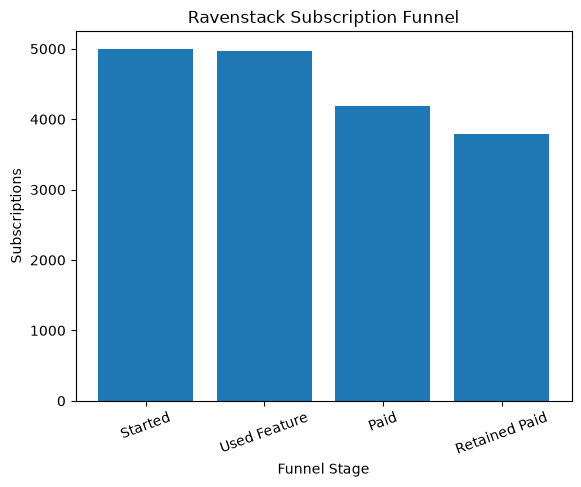

전환율이 가장 낮은 구간:
기능 사용 -> 유료 구독
전환율: 84.42 %


In [2]:
# 필수 1 코드를 작성하세요.
started_ids = set(subscriptions["subscription_id"].dropna().unique())

used_ids = started_ids & set(
    feature_usage["subscription_id"].dropna().unique()
)

paid_ids = used_ids & set(
    subscriptions.loc[
        subscriptions["is_trial"] == False,
        "subscription_id"
    ].dropna().unique()
)

retained_paid_ids = paid_ids & set(
    subscriptions.loc[
        subscriptions["end_date"].isna(),
        "subscription_id"
    ].dropna().unique()
)

funnel = pd.DataFrame({
    "단계": [
        "구독 시작",
        "기능 사용",
        "유료 구독",
        "현재 유료 유지"
    ],
    "구독 수": [
        len(started_ids),
        len(used_ids),
        len(paid_ids),
        len(retained_paid_ids)
    ]
})

funnel["전환율"] = (
    funnel["구독 수"]
    / funnel["구독 수"].shift(1)
)

funnel["이탈률"] = 1 - funnel["전환율"]

funnel["이탈 구독 수"] = (
    funnel["구독 수"].shift(1)
    - funnel["구독 수"]
)

print(funnel)

plt.bar(
    ["Started", "Used Feature", "Paid", "Retained Paid"],
    funnel["구독 수"]
)

plt.xlabel("Funnel Stage")
plt.ylabel("Subscriptions")
plt.title("Ravenstack Subscription Funnel")
plt.xticks(rotation=20)

plt.show()

funnel_section = funnel.iloc[1:].copy()

lowest_conversion_index = funnel_section["전환율"].idxmin()

previous_stage = funnel.loc[
    lowest_conversion_index - 1,
    "단계"
]

lowest_stage = funnel.loc[
    lowest_conversion_index,
    "단계"
]

lowest_rate = funnel.loc[
    lowest_conversion_index,
    "전환율"
]

print("전환율이 가장 낮은 구간:")
print(previous_stage, "->", lowest_stage)
print("전환율:", round(lowest_rate * 100, 2), "%")

### 필수 1 답변 작성란

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?
  - 같은 구독에서 기능 사용 이벤트가 여러 번 발생할 수 있다.
  - 중복 계산이 될 위험성이 있다.

**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?
  - 기능 사용 > 유료 구독 구간, 전환율은 약 84.42%, 이탈 구속 수는 774개

**Q3.** 전환율과 이탈률을 더하면 얼마인가요?
  - 100% 
  - 이탈율 = 1 - 전환율로 계산

**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?
  - 없다. 퍼널은 사용자가 많이 줄어든 위치를 보여 주지만
    가격, 성능, 기능 부족 등 어떤 이유로 줄었는지는 원인 파악이 추가적으로 필요하다.

---

## 필수 2. 요금제별 퍼널 비교하기

### 문제 2-1. 요금제에 따라 이탈 구간이 다른가?

#### 문제 설명

`Basic`, `Pro`, `Enterprise` 요금제별로 동일한 퍼널을 계산하고 구간 전환율을 비교하세요. 그룹별 비교를 통해 특정 요금제에 문제가 집중되어 있는지 확인합니다.

#### 요구사항

1. 요금제별 퍼널을 계산하는 함수 `calculate_segment_funnel()`을 작성하세요.
2. 함수는 필수 1과 동일한 네 단계의 고유 구독 수와 구간 전환율을 반환해야 합니다.
3. 세 요금제의 결과를 결합하여 `plan_funnel`을 만드세요.
4. 첫 단계를 제외한 구간별 전환율을 요금제별 막대그래프로 시각화하세요.
5. 모든 요금제와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
6. 해당 요금제와 구간을 우선 점검 대상으로 정하고 개선 가설을 한 가지 제안하세요.
7. 요금제별 차이가 크지 않을 경우 해석에서 그 사실도 언급하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?  
**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?

#### 제출 결과

- 요금제별 퍼널 계산 함수
- `plan_funnel` 결과
- 요금제별 전환율 그래프
- 우선 점검 대상과 개선 가설
- Q1~Q4 답변

           요금제        단계  구독 수     전환율     이탈률
0        Basic     구독 시작  1602       -       -
1        Basic     기능 사용  1588  99.13%   0.87%
2        Basic     유료 구독  1343  84.57%  15.43%
3        Basic  현재 유료 유지  1217  90.62%   9.38%
4          Pro     구독 시작  1675       -       -
5          Pro     기능 사용  1665  99.40%   0.60%
6          Pro     유료 구독  1407  84.50%  15.50%
7          Pro  현재 유료 유지  1273  90.48%   9.52%
8   Enterprise     구독 시작  1723       -       -
9   Enterprise     기능 사용  1714  99.48%   0.52%
10  Enterprise     유료 구독  1443  84.19%  15.81%
11  Enterprise  현재 유료 유지  1298  89.95%  10.05%


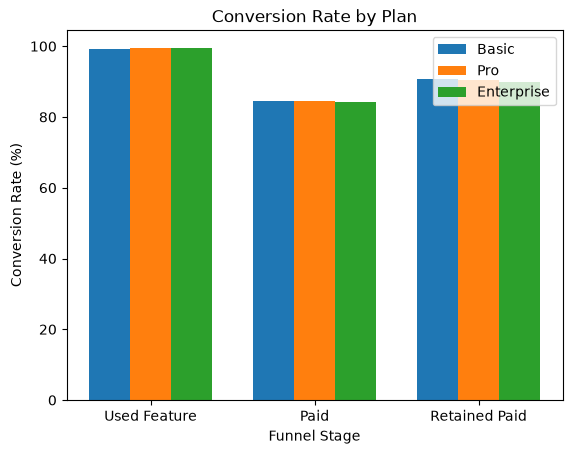

전환율이 가장 낮은 조합
요금제: Enterprise
구간: 유료 구독
전환율: 84.19%
이탈률: 15.81%

개선 가설
Enterprise 요금제 사용자가 유료 기능의 가치나 혜택을 충분히 인식하지 못하고 있을 가능성이 있으므로 유료 기능과 업그레이드 혜택을 명확하게 안내하면 전환율이 개선될 수 있다.


In [3]:
# 필수 2 코드를 작성하세요.
def calculate_segment_funnel(plan_name):
    segment_subscriptions = subscriptions[
        subscriptions["plan_tier"] == plan_name
    ]

    started_ids = set(
        segment_subscriptions["subscription_id"].dropna().unique()
    )

    used_ids = started_ids & set(
        feature_usage["subscription_id"].dropna().unique()
    )

    paid_ids = used_ids & set(
        segment_subscriptions.loc[
            segment_subscriptions["is_trial"] == False,
            "subscription_id"
        ].dropna().unique()
    )

    retained_paid_ids = paid_ids & set(
        segment_subscriptions.loc[
            segment_subscriptions["end_date"].isna(),
            "subscription_id"
        ].dropna().unique()
    )

    segment_funnel = pd.DataFrame({
        "요금제": [plan_name] * 4,
        "단계": [
            "구독 시작",
            "기능 사용",
            "유료 구독",
            "현재 유료 유지"
        ],
        "구독 수": [
            len(started_ids),
            len(used_ids),
            len(paid_ids),
            len(retained_paid_ids)
        ]
    })

    segment_funnel["전환율"] = (
        segment_funnel["구독 수"]
        / segment_funnel["구독 수"].shift(1)
    )

    segment_funnel["이탈률"] = (
        1 - segment_funnel["전환율"]
    )

    return segment_funnel


basic_funnel = calculate_segment_funnel("Basic")
pro_funnel = calculate_segment_funnel("Pro")
enterprise_funnel = calculate_segment_funnel("Enterprise")

plan_funnel = pd.concat(
    [basic_funnel, pro_funnel, enterprise_funnel],
    ignore_index=True
)

plan_funnel["전환율"] = plan_funnel["전환율"].apply(
    lambda x: f"{x * 100:.2f}%" if pd.notna(x) else "-"
)

plan_funnel["이탈률"] = plan_funnel["이탈률"].apply(
    lambda x: f"{x * 100:.2f}%" if pd.notna(x) else "-"
)

print(plan_funnel)


conversion_data = pd.concat(
    [basic_funnel, pro_funnel, enterprise_funnel],
    ignore_index=True
)

conversion_data = conversion_data[
    conversion_data["단계"] != "구독 시작"
].copy()

stage_order = [
    "기능 사용",
    "유료 구독",
    "현재 유료 유지"
]

stage_labels = [
    "Used Feature",
    "Paid",
    "Retained Paid"
]

plans = ["Basic", "Pro", "Enterprise"]

x = range(len(stage_order))
width = 0.25

for i, plan in enumerate(plans):
    plan_data = (
        conversion_data[
            conversion_data["요금제"] == plan
        ]
        .set_index("단계")
        .loc[stage_order]
    )

    plt.bar(
        [value + i * width for value in x],
        plan_data["전환율"] * 100,
        width=width,
        label=plan
    )

plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Plan")
plt.xticks(
    [value + width for value in x],
    stage_labels
)
plt.legend()
plt.show()


lowest_index = conversion_data["전환율"].idxmin()

lowest_plan = conversion_data.loc[
    lowest_index,
    "요금제"
]

lowest_stage = conversion_data.loc[
    lowest_index,
    "단계"
]

lowest_rate = conversion_data.loc[
    lowest_index,
    "전환율"
]

lowest_dropoff = conversion_data.loc[
    lowest_index,
    "이탈률"
]

print("전환율이 가장 낮은 조합")
print("요금제:", lowest_plan)
print("구간:", lowest_stage)
print(f"전환율: {lowest_rate * 100:.2f}%")
print(f"이탈률: {lowest_dropoff * 100:.2f}%")

print("\n개선 가설")

if lowest_stage == "기능 사용":
    print(
        f"{lowest_plan} 요금제 사용자가 구독 후 기능을 충분히 사용하지 못하고 "
        "있을 가능성이 있으므로 초기 기능 안내와 온보딩을 강화하면 "
        "기능 사용 전환율이 개선될 수 있다."
    )

elif lowest_stage == "유료 구독":
    print(
        f"{lowest_plan} 요금제 사용자가 유료 기능의 가치나 혜택을 충분히 "
        "인식하지 못하고 있을 가능성이 있으므로 유료 기능과 업그레이드 "
        "혜택을 명확하게 안내하면 전환율이 개선될 수 있다."
    )

elif lowest_stage == "현재 유료 유지":
    print(
        f"{lowest_plan} 요금제의 유료 사용자가 가격이나 서비스 가치에 "
        "만족하지 못해 이탈할 가능성이 있으므로 유지 고객의 이용 패턴과 "
        "이탈 원인을 분석하고 유지 혜택을 강화할 필요가 있다."
    )

### 필수 2 답변 작성란

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?
  - Enterprise 요금제의 기능 사용 > 유료 구독 구간, 전환율은 84.19%

**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?
  - 전체 결과에서는 쉽게 볼 수 없는 특정 요금제의 상대적으로 낮은 구간을 찾을 수 있어 개선 대상을 더 구체적으로 정할 수 있음.

**Q3.** 관찰된 요금제별 차이는 큰 편인가요? 
  - 아닙니다. 기능 사용에서 유료 구독으로 이어지는 전환율은 세 요금제 모두 약 84% 정도로 차이가 적다.

**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?
  - 체험 종료 데이터, 이탈 사유, 고객 문의 데이터

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 퍼널 비교하기

#### 문제 설명

월간 결제 구독과 연간 결제 구독의 퍼널을 비교하여 상대적으로 전환율이 낮은 그룹과 구간을 찾으세요.

> 이 과제는 필수 2에서 만든 함수와 분석 절차를 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. `calculate_segment_funnel()`을 사용하여 `monthly`, `annual`의 퍼널을 계산하세요.
2. 두 결과를 결합하여 `billing_funnel`을 만드세요.
3. 첫 단계를 제외한 구간 전환율을 결제 주기별 막대그래프로 시각화하세요.
4. 모든 결제 주기와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
5. 해당 그룹과 구간에 대한 개선 가설을 한 가지 제안하세요.
  - monthly 구독은 언제든 해지할 수 있어 체험 후 유료 전환 결정을 미룰 수 있다.
6. 퍼널 결과만으로 원인을 확정할 수 없는 이유와 추가 확인할 데이터를 설명하세요.
  - 퍼널 결과는 어느 구간에서 이탈이 큰지는 보여주지만 원인까지 설명하지는 못한다.
  - 이탈 사유, 기능 사용 패턴, 고객 문의 데이터 등을 추가로 확인할 필요가 있다.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?

#### 제출 결과

- `billing_funnel` 결과
- 결제 주기별 전환율 그래프
- 우선 점검 대상과 개선 가설
- 분석의 한계와 추가 확인 데이터
- Q1~Q3 답변

     결제 주기        단계  구독 수       전환율       이탈률
0  monthly     구독 시작  2539       NaN       NaN
1  monthly     기능 사용  2520  0.992517  0.007483
2  monthly     유료 구독  2120  0.841270  0.158730
3  monthly  현재 유료 유지  1930  0.910377  0.089623
4   annual     구독 시작  2461       NaN       NaN
5   annual     기능 사용  2447  0.994311  0.005689
6   annual     유료 구독  2073  0.847160  0.152840
7   annual  현재 유료 유지  1858  0.896286  0.103714


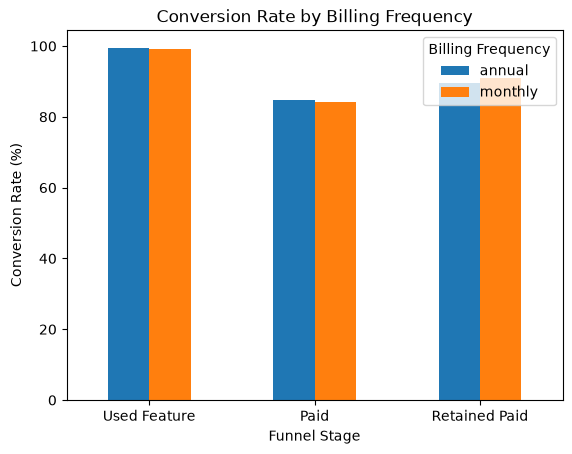

가장 낮은 조합: monthly / 유료 구독
전환율: 84.13%, 이탈률: 15.87%


In [10]:
# 과제 1 코드를 작성하세요.
def calculate_segment_funnel(value, col="plan_tier", label="요금제"):
    seg = subscriptions[subscriptions[col] == value]
    started = set(seg["subscription_id"])
    used = started & set(feature_usage["subscription_id"])
    paid = used & set(seg.loc[~seg["is_trial"], "subscription_id"])
    retained = paid & set(seg.loc[seg["end_date"].isna(), "subscription_id"])

    df = pd.DataFrame({
        label: value,
        "단계": ["구독 시작", "기능 사용", "유료 구독", "현재 유료 유지"],
        "구독 수": [len(started), len(used), len(paid), len(retained)]
    })
    df["전환율"] = df["구독 수"] / df["구독 수"].shift(1)
    df["이탈률"] = 1 - df["전환율"]
    return df


billing_funnel = pd.concat(
    [calculate_segment_funnel(b, "billing_frequency", "결제 주기") for b in ["monthly", "annual"]],
    ignore_index=True
)
print(billing_funnel)

conversion_data = billing_funnel[billing_funnel["단계"] != "구독 시작"]

(conversion_data
    .pivot(index="단계", columns="결제 주기", values="전환율")
    .loc[["기능 사용", "유료 구독", "현재 유료 유지"]]
    .mul(100)
    .plot(kind="bar", rot=0))
plt.xticks(range(3), ["Used Feature", "Paid", "Retained Paid"])
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Billing Frequency")
plt.legend(title="Billing Frequency")
plt.show()

lowest = conversion_data.loc[conversion_data["전환율"].idxmin()]
print(f"가장 낮은 조합: {lowest['결제 주기']} / {lowest['단계']}")
print(f"전환율: {lowest['전환율']:.2%}, 이탈률: {lowest['이탈률']:.2%}")

### 과제 1 답변 작성란

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?
  - monthly의 기능 사용 > 유료 구독 구간이다.

**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
  - 전환율: 84.13%, 이탈률: 15.87%

**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?
  - 없다. monthly(84.13%)와 annual(84.72%)의 차이는 0.59%p로 작고, 결제 주기는 고객이 선택한 것이라 요금제 등 다른 특성이 섞여 있을 수 있다.

---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 실습의 퍼널 단계를 어떻게 정의했나요?
  - 구독 여부 > 기능 사용 > 유료 구독 > 구독 유지(종료 데이터가 없는)
  - 이렇게 4단계로 구분

2. 단계별 사용자 수 대신 어떤 식별자의 고유 개수를 사용했나요?
  - 구독자 ID의 고유값을 사용했다.

3. 전환율과 이탈률은 어떻게 계산했나요?
  - 현재 단계 구독 수를 이전 단계 구독 수로 나누어 전환율을 계산하고
  - 1에서 전환율을 빼서 이탈율을 계산

4. 전체 퍼널에서 가장 큰 문제가 나타난 구간은 어디였나요?
  - 기능 > 유료 구독 약 84%의 전환율, 이탈율은 16%
  
5. 퍼널 분석 결과와 실제 원인을 왜 구분해야 하나요?
  - 퍼널은 어느 구간에서 사용자가 줄었는지 보여 주지만
    가격, 기능, 문의 등 어떤 요인이 원인이었는지 직접 알려 주지는 않는다.